In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("world_happiness_2015_2019.xlsx")

df.head()

,Year,Country,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
0,2015,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678
1,2015,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630
2,2015,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139
3,2015,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699
4,2015,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811


In [2]:
df.shape

(782, 9)

In [3]:
df.columns

Index(['Year', 'Country', 'Happiness Score', 'Economy (GDP per Capita)',
       'Family', 'Health (Life Expectancy)', 'Freedom',
       'Trust (Government Corruption)', 'Generosity'],
      dtype='object')

In [4]:
top10 = (
    df.groupby("Country")["Happiness Score"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top10

,Happiness Score
Country,
Denmark,7.5460
Norway,7.5410
Finland,7.5378
Switzerland,7.5114
Iceland,7.5110
Netherlands,7.4046
Canada,7.3506
Sweden,7.3192
New Zealand,7.3130


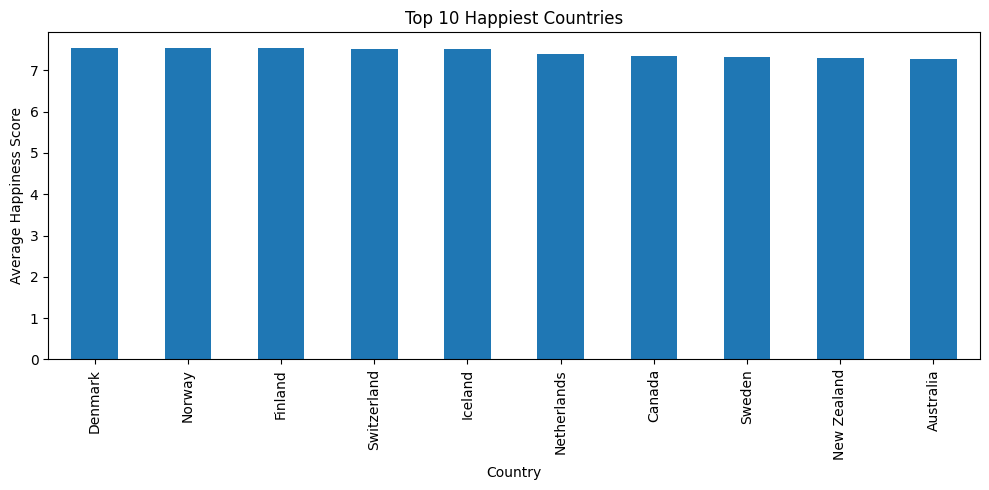

In [5]:
plt.figure(figsize=(10,5))

top10.plot(kind="bar")

plt.title("Top 10 Happiest Countries")
plt.ylabel("Average Happiness Score")

plt.tight_layout()
plt.show()

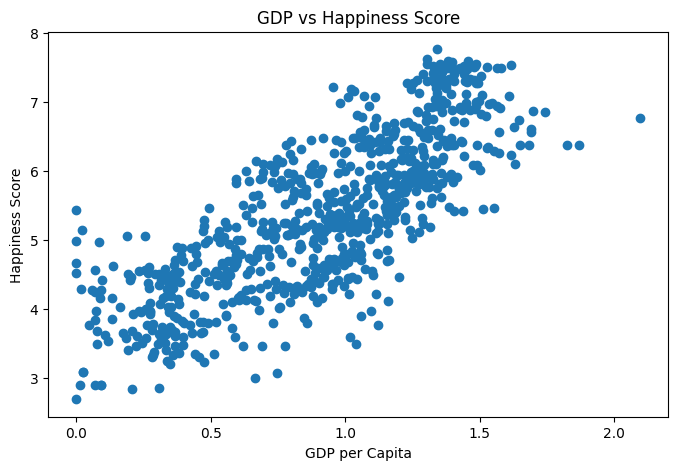

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Economy (GDP per Capita)"],
    df["Happiness Score"]
)

plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")

plt.title("GDP vs Happiness Score")

plt.show()

There is a clear positive relationship between GDP per capita and happiness score. Countries with higher GDP per capita tend to have higher happiness scores.

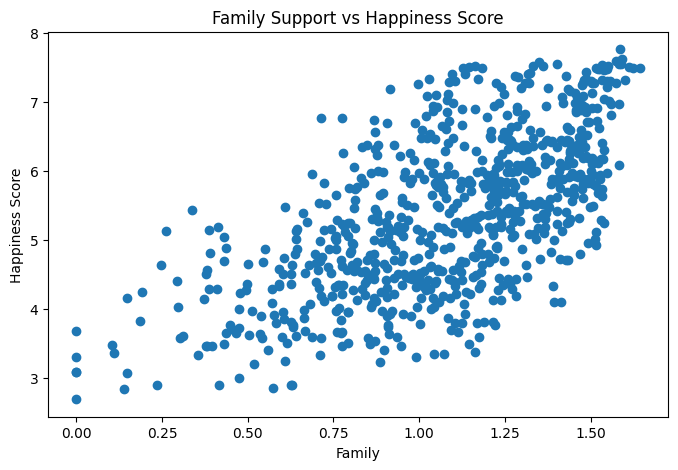

Family support shows a strong positive relationship with happiness score. Countries with stronger social and family support systems generally report higher levels of happiness.

In [8]:
import seaborn as sns

In [9]:
features = [
    "Economy (GDP per Capita)",
    "Family",
    "Health (Life Expectancy)",
    "Freedom",
    "Trust (Government Corruption)",
    "Generosity",
    "Happiness Score"
]

corr = df[features].corr()

corr

,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Happiness Score
Economy (GDP per Capita),1.000000,0.585966,0.784338,0.340511,0.306307,-0.014560,0.789284
Family,0.585966,1.000000,0.572650,0.420361,0.126401,-0.037262,0.648799
Health (Life Expectancy),0.784338,0.572650,1.000000,0.340745,0.250512,0.010638,0.742456
Freedom,0.340511,0.420361,0.340745,1.000000,0.459593,0.290706,0.551258
Trust (Government Corruption),0.306307,0.126401,0.250512,0.459593,1.000000,0.318920,0.398418
Generosity,-0.014560,-0.037262,0.010638,0.290706,0.318920,1.000000,0.137578
Happiness Score,0.789284,0.648799,0.742456,0.551258,0.398418,0.137578,1.000000


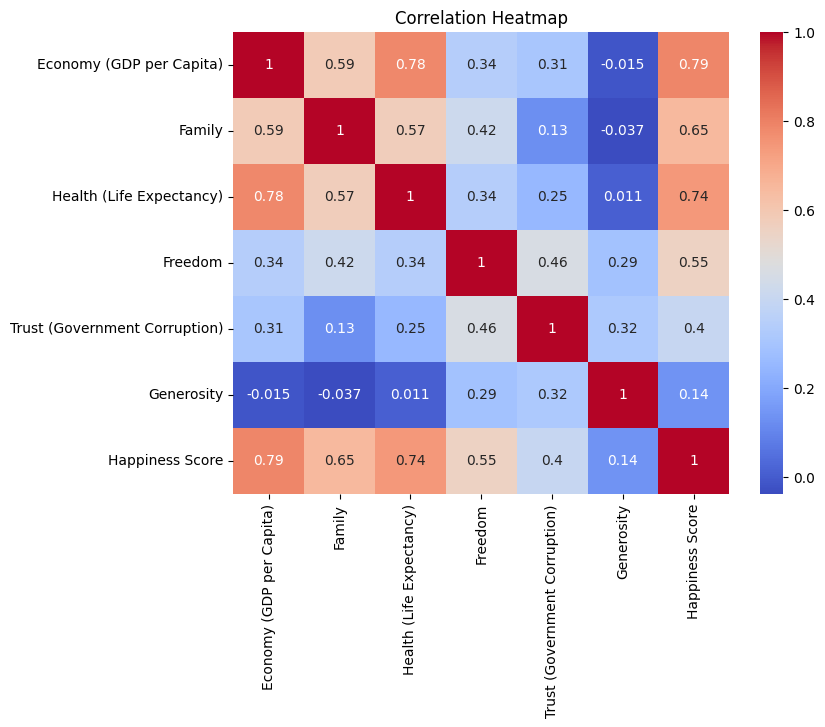

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

#conclusion1
GDP per capita has the strongest correlation with happiness score (0.79).
#conclusion2
Health (Life Expectancy) is also strongly associated with happiness score (0.74).
#conclusion3
Family support shows a strong positive relationship with happiness score (0.65).
#conclusion4
Generosity has the weakest correlation with happiness score (0.14).


In [11]:
yearly = df.groupby("Year")["Happiness Score"].mean()

yearly

,Happiness Score
Year,
2015,5.375734
2016,5.382185
2017,5.354019
2018,5.375917
2019,5.407096


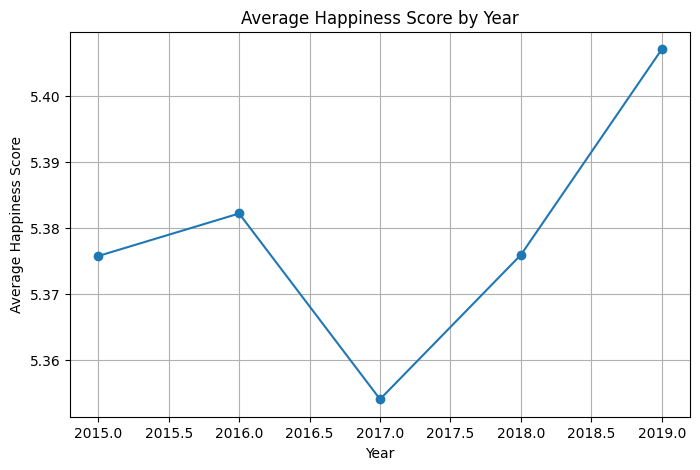

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly.index,
    yearly.values,
    marker="o"
)

plt.title("Average Happiness Score by Year")

plt.xlabel("Year")
plt.ylabel("Average Happiness Score")

plt.grid(True)

plt.show()

Global average happiness scores remained relatively stable between 2015 and 2019, with a slight increase by 2019.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [20]:
df.isnull().sum()

,0
Year,0
Country,0
Happiness Score,0
Economy (GDP per Capita),0
Family,0
Health (Life Expectancy),0
Freedom,0
Trust (Government Corruption),1
Generosity,0


In [21]:
df_ml = df.dropna()

In [22]:
X = df_ml[
[
    "Economy (GDP per Capita)",
    "Family",
    "Health (Life Expectancy)",
    "Freedom",
    "Trust (Government Corruption)",
    "Generosity"
]
]
y = df_ml["Happiness Score"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [25]:
pred = model.predict(X_test)

print("R2 Score =", r2_score(y_test, pred))

R2 Score = 0.7465230243518592


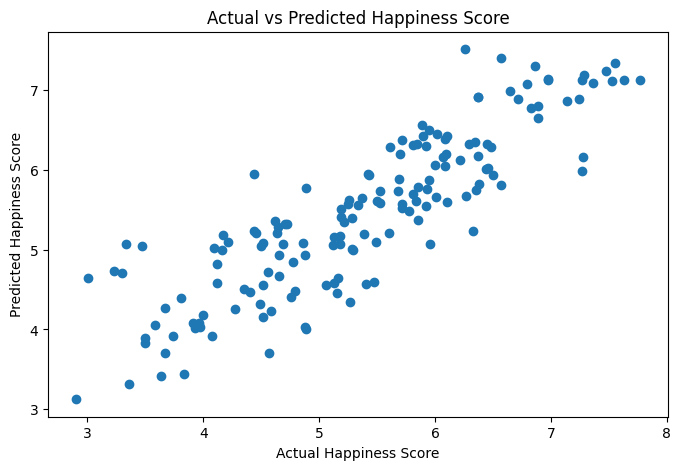

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, pred)

plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")

plt.title("Actual vs Predicted Happiness Score")

plt.show()

In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
rf_pred = rf.predict(X_test)

print(
    "Random Forest R2 =",
    r2_score(y_test, rf_pred)
)

Random Forest R2 = 0.7933952765934467
